# CIFAR10-DVS classification — testing the event vision encoder at T=5

A capability check for `EventVisionEncoder`: if it cannot learn 10-way classification
from event cubes, it will not support referring-expression grounding either. CIFAR10-DVS
is the right probe because it is labelled, event-native, and small enough to train in
minutes.

## The cube layout

Each sample is voxelized to **T = 5 timesteps × 2 polarity bins = 10 channels total**,
at the sensor's native 128×128:

```
cube shape (T, C, H, W) = (5, 2, 128, 128)
    T = 5   simulation steps the SNN runs, membrane state carried across them
    C = 2   one channel per polarity (OFF, ON) within each step
            -> 5 x 2 = 10 channels of event counts in total
```

This mirrors how Talk2Event is organised (10 steps × 2 polarities = 20 channels), so the
same encoder consumes both — only `in_channels` (=2, per step) and the spatial size differ.

Unlike Talk2Event, CIFAR10-DVS ships **raw asynchronous event streams**, so the cube is
built here from real timestamps rather than reshaped from a pre-binned file.

In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

from spiketrandvg.datasets.cifar10_dvs import CLASSES, CIFAR10DVSVoxel
from spiketrandvg.models.event_classifier import EventClassifier

# ---- configuration -------------------------------------------------------
T_STEPS = 5          # simulation steps
TBIN = 1             # micro-bins per step -> C = 2*TBIN = 2 channels per step
BATCH = 8
EPOCHS = 5           # raise to ~30 for a real run (tools/train_cifar10_dvs.py does this)
LR = 1e-4
WORKERS = 8
TAP = "s16b"         # final backbone stage, 640 ch
# resolved from the package location so it works whatever the working directory is
import spiketrandvg
from pathlib import Path
CKPT = str(Path(spiketrandvg.__file__).resolve().parents[2]
           / "ckpts" / "spikeformer_v2_weights" / "55M_kd_T4.pth")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(0)
plt.rcParams["figure.dpi"] = 110
print(f"device: {DEVICE} | T={T_STEPS} tbin={TBIN} -> {2*TBIN} channels/step, "
      f"{T_STEPS * 2 * TBIN} total")

device: cuda | T=5 tbin=1 -> 2 channels/step, 10 total


## 1. Dataset

The first call voxelizes all 10,000 recordings into a `uint8` memmap (~1.5 GiB) and
reuses it afterwards — decoding `.aedat` costs ~26 ms per file, which would otherwise
dominate every epoch. The 9:1 split is deterministic and class-stratified (there is no
official split for this dataset).

In [2]:
train_ds = CIFAR10DVSVoxel(split="train", T=T_STEPS, tbin=TBIN, workers=WORKERS)
test_ds = CIFAR10DVSVoxel(split="test", T=T_STEPS, tbin=TBIN, workers=WORKERS)

cube, label = train_ds[0]
print(f"train {len(train_ds)} | test {len(test_ds)}")
print(f"cube {tuple(cube.shape)} {cube.dtype}  counts 0..{int(cube.max())}")
print(f"label {label} = {CLASSES[label]}")
print(f"no train/test leakage: {len(set(train_ds.indices) & set(test_ds.indices)) == 0}")

counts = np.bincount(train_ds.labels_all[train_ds.indices], minlength=10)
print(f"per-class train counts: {counts.tolist()}")

train_ld = DataLoader(train_ds, batch_size=BATCH, shuffle=True,
                      num_workers=WORKERS, pin_memory=True, drop_last=True)
test_ld = DataLoader(test_ds, batch_size=BATCH, shuffle=False,
                     num_workers=WORKERS, pin_memory=True)

train 9000 | test 1000
cube (5, 2, 128, 128) torch.float32  counts 0..19
label 0 = airplane
no train/test leakage: True
per-class train counts: [900, 900, 900, 900, 900, 900, 900, 900, 900, 900]


/home/karthik/Desktop/PhD/talk2events_research/spiketrandvg/src/spiketrandvg/datasets/cifar10_dvs.py:143: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /__w/pytorch/pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  cube = torch.from_numpy(np.asarray(self.data[j])).float()


## 2. What a sample looks like

One recording across its 5 timesteps. CIFAR10-DVS was produced by replaying CIFAR-10
images on a monitor while panning, so events trace the moving edges of the object.

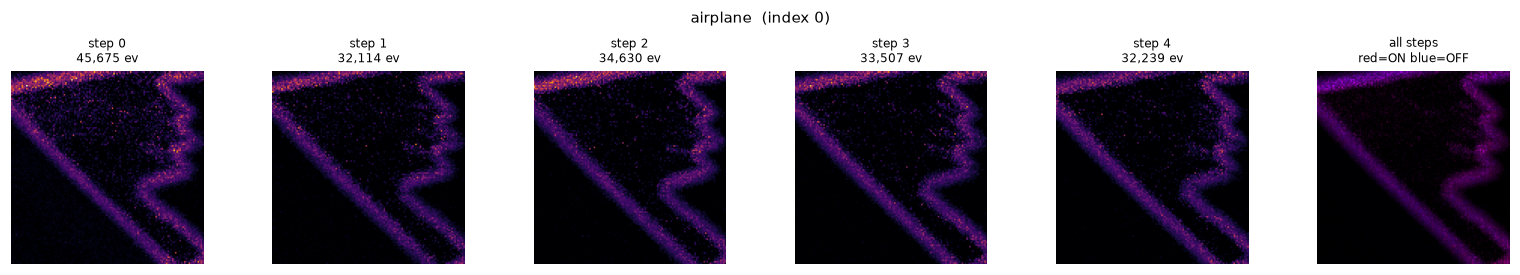

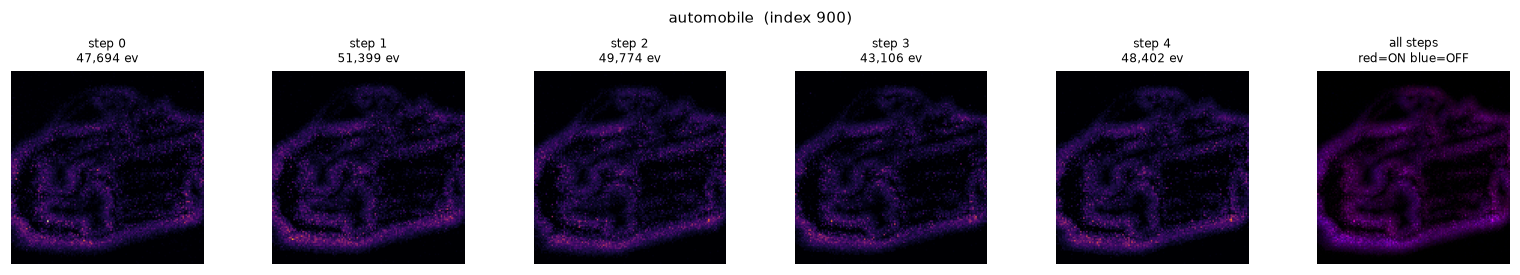

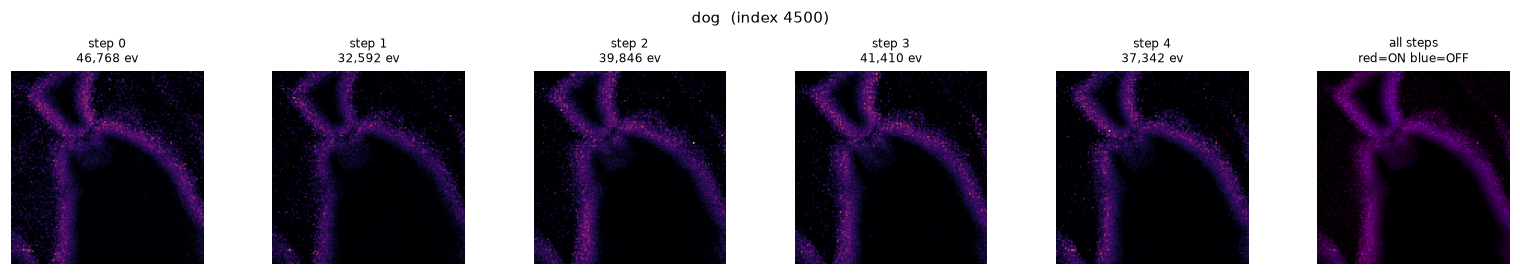

In [3]:
def show_sample(ds, i):
    cube, lab = ds[i]
    per_step = cube.sum(1).numpy()            # both polarities, per step
    vmax = per_step.max()
    fig, axes = plt.subplots(1, T_STEPS + 1, figsize=(2.4 * (T_STEPS + 1), 2.5))
    for s in range(T_STEPS):
        axes[s].imshow(per_step[s], cmap="inferno", vmin=0, vmax=vmax)
        axes[s].set_title(f"step {s}\n{int(per_step[s].sum()):,} ev", fontsize=8)
        axes[s].axis("off")
    # accumulated, ON vs OFF as red/blue
    on, off = cube[:, 1].sum(0).numpy(), cube[:, 0].sum(0).numpy()
    rgb = np.zeros((*on.shape, 3))
    sc = max(on.max(), off.max(), 1)
    rgb[..., 0], rgb[..., 2] = on / sc, off / sc
    axes[-1].imshow(rgb)
    axes[-1].set_title("all steps\nred=ON blue=OFF", fontsize=8)
    axes[-1].axis("off")
    fig.suptitle(f"{CLASSES[lab]}  (index {i})", fontsize=10)
    plt.tight_layout(); plt.show()


for i in [0, 900, 4500]:
    show_sample(train_ds, i)

## 3. Model

`EventClassifier` = `EventVisionEncoder` (Meta-SpikeFormer, ImageNet-initialised, stem
adapted from 3 RGB channels to 2 polarity channels) followed by the same readout the
backbone's own classifier uses: spatial mean → LIF → Linear → mean over timesteps.

In [4]:
model = EventClassifier(
    num_classes=len(CLASSES), in_channels=2 * TBIN, tap=TAP, ckpt_path=CKPT,
).to(DEVICE)

total = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"params: {total/1e6:.1f}M ({trainable/1e6:.1f}M trainable)")

# shape check before training
with torch.no_grad():
    probe = torch.stack([train_ds[i][0] for i in range(2)]).to(DEVICE)
    probe = probe.permute(1, 0, 2, 3, 4)        # (B,T,C,H,W) -> (T,B,C,H,W)
    print(f"input {tuple(probe.shape)} -> logits {tuple(model(probe).shape)}")

/home/karthik/Desktop/PhD/talk2events_research/spiketrandvg/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/karthik/Desktop/PhD/talk2events_research/spiketrandvg/.venv/lib/python3.12/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/home/karthik/Desktop/PhD/talk2events_research/spiketrandvg/.venv/lib/python3.12/site-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)


[event_encoder] /home/karthik/Desktop/PhD/talk2events_research/spiketrandvg/ckpts/spikeformer_v2_weights/55M_kd_T4.pth: loaded 823/827 tensors (missing 0, unexpected 4), stem 3ch -> 2ch
params: 54.7M (54.7M trainable)
input (5, 2, 2, 128, 128) -> logits (2, 10)


## 4. Train

The DataLoader yields `(B, T, C, H, W)`; the encoder wants time first, hence the
`permute`. `model.forward` resets every membrane at entry, so no state leaks between
samples — without that reset the second `backward()` fails on a freed graph.

In [5]:
@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    preds, labels = [], []
    for cube, lab in loader:
        cube = cube.to(DEVICE, non_blocking=True).permute(1, 0, 2, 3, 4)
        preds.append(model(cube).argmax(1).cpu())
        labels.append(lab)
    preds, labels = torch.cat(preds), torch.cat(labels)
    return (preds == labels).float().mean().item(), preds.numpy(), labels.numpy()


opt = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad],
                        lr=LR, weight_decay=1e-4)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)
crit = nn.CrossEntropyLoss()

history = {"train_loss": [], "train_acc": [], "test_acc": []}

for epoch in range(EPOCHS):
    model.train()
    t0, run_loss, hit, seen = time.time(), 0.0, 0, 0
    for i, (cube, lab) in enumerate(train_ld):
        cube = cube.to(DEVICE, non_blocking=True).permute(1, 0, 2, 3, 4)
        lab = lab.to(DEVICE, non_blocking=True)
        logits = model(cube)
        loss = crit(logits, lab)
        opt.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            [p for p in model.parameters() if p.requires_grad], 5.0)
        opt.step()
        run_loss += loss.item() * lab.numel()
        hit += (logits.argmax(1) == lab).sum().item()
        seen += lab.numel()
        if (i + 1) % 100 == 0:
            print(f"  epoch {epoch} iter {i+1}/{len(train_ld)} "
                  f"loss {run_loss/seen:.4f} acc {hit/seen:.4f}", flush=True)
    sched.step()
    test_acc, _, _ = evaluate(model, test_ld)
    history["train_loss"].append(run_loss / seen)
    history["train_acc"].append(hit / seen)
    history["test_acc"].append(test_acc)
    print(f"== epoch {epoch}: loss {run_loss/seen:.4f} "
          f"train_acc {hit/seen:.4f} | TEST ACC {test_acc:.4f} "
          f"| {time.time()-t0:.0f}s", flush=True)

print(f"\nbest test accuracy: {max(history['test_acc']):.4f} "
      f"(chance = {1/len(CLASSES):.2f})")

  epoch 0 iter 100/1125 loss 2.0302 acc 0.2838
  epoch 0 iter 200/1125 loss 1.8083 acc 0.3650
  epoch 0 iter 300/1125 loss 1.6517 acc 0.4267


  epoch 0 iter 400/1125 loss 1.5448 acc 0.4653
  epoch 0 iter 500/1125 loss 1.4616 acc 0.4980
  epoch 0 iter 600/1125 loss 1.3985 acc 0.5210
  epoch 0 iter 700/1125 loss 1.3413 acc 0.5425
  epoch 0 iter 800/1125 loss 1.2882 acc 0.5634
  epoch 0 iter 900/1125 loss 1.2462 acc 0.5796
  epoch 0 iter 1000/1125 loss 1.2139 acc 0.5907
  epoch 0 iter 1100/1125 loss 1.1852 acc 0.6009
== epoch 0: loss 1.1776 train_acc 0.6036 | TEST ACC 0.7460 | 115s
  epoch 1 iter 100/1125 loss 0.7989 acc 0.7350
  epoch 1 iter 200/1125 loss 0.7815 acc 0.7444
  epoch 1 iter 300/1125 loss 0.7560 acc 0.7529
  epoch 1 iter 400/1125 loss 0.7559 acc 0.7550
  epoch 1 iter 500/1125 loss 0.7520 acc 0.7550
  epoch 1 iter 600/1125 loss 0.7535 acc 0.7525
  epoch 1 iter 700/1125 loss 0.7438 acc 0.7559
  epoch 1 iter 800/1125 loss 0.7324 acc 0.7595
  epoch 1 iter 900/1125 loss 0.7287 acc 0.7601
  epoch 1 iter 1000/1125 loss 0.7252 acc 0.7621
  epoch 1 iter 1100/1125 loss 0.7254 acc 0.7623
== epoch 1: loss 0.7242 train_acc 0.7

## 5. Curves

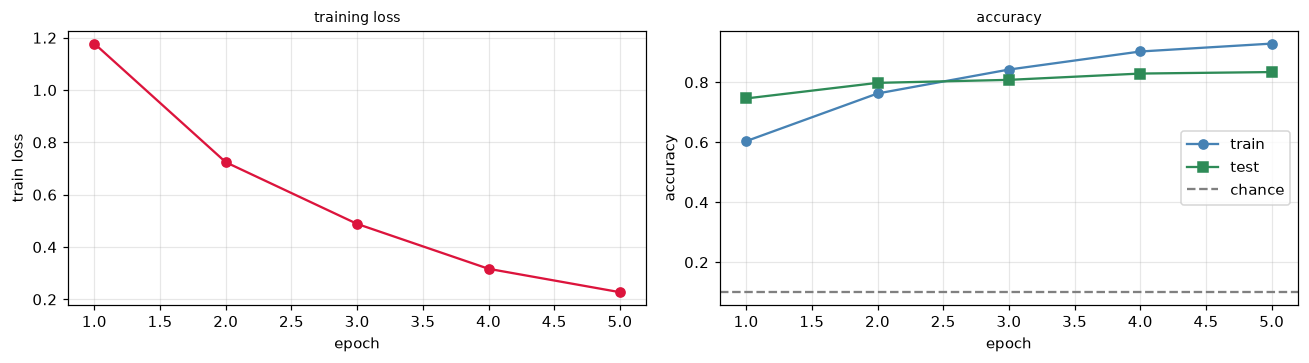

In [6]:
ep = np.arange(1, len(history["train_loss"]) + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 3.4))
axes[0].plot(ep, history["train_loss"], "o-", color="crimson")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("train loss")
axes[0].set_title("training loss", fontsize=9); axes[0].grid(alpha=0.3)

axes[1].plot(ep, history["train_acc"], "o-", label="train", color="steelblue")
axes[1].plot(ep, history["test_acc"], "s-", label="test", color="seagreen")
axes[1].axhline(1 / len(CLASSES), ls="--", c="grey", label="chance")
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("accuracy")
axes[1].set_title("accuracy", fontsize=9); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 6. Per-class accuracy and confusion matrix

Worth reading even at low overall accuracy: a model that has latched onto one or two
easy classes looks very different from one learning uniformly, and only the confusion
matrix distinguishes them.

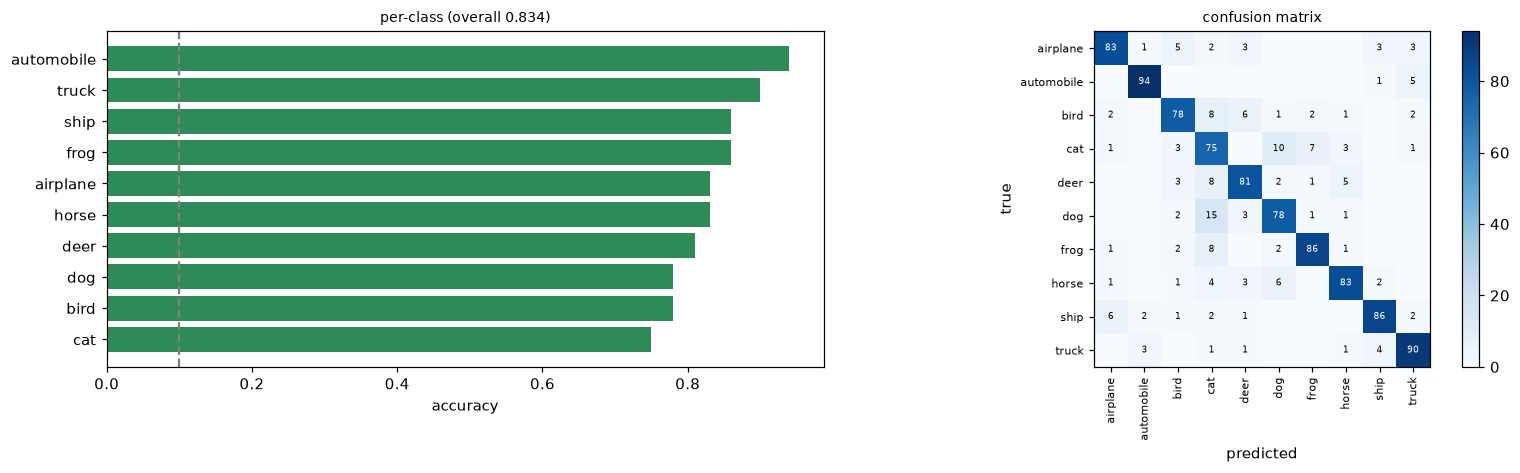

per-class: automobile 0.94, truck 0.90, ship 0.86, frog 0.86, airplane 0.83, horse 0.83, deer 0.81, dog 0.78, bird 0.78, cat 0.75


In [7]:
acc, preds, labels = evaluate(model, test_ld)
K = len(CLASSES)
cm = np.zeros((K, K), dtype=int)
for p, l in zip(preds, labels):
    cm[l, p] += 1
per_cls = cm.diagonal() / np.maximum(cm.sum(1), 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.4),
                         gridspec_kw={"width_ratios": [1.1, 1]})
order = np.argsort(per_cls)[::-1]
axes[0].barh([CLASSES[i] for i in order], per_cls[order], color="seagreen")
axes[0].axvline(1 / K, ls="--", c="grey")
axes[0].set_xlabel("accuracy"); axes[0].set_title(
    f"per-class (overall {acc:.3f})", fontsize=9)
axes[0].invert_yaxis()

im = axes[1].imshow(cm, cmap="Blues")
axes[1].set_xticks(range(K)); axes[1].set_xticklabels(CLASSES, rotation=90, fontsize=7)
axes[1].set_yticks(range(K)); axes[1].set_yticklabels(CLASSES, fontsize=7)
axes[1].set_xlabel("predicted"); axes[1].set_ylabel("true")
axes[1].set_title("confusion matrix", fontsize=9)
for a in range(K):
    for b in range(K):
        if cm[a, b]:
            axes[1].text(b, a, cm[a, b], ha="center", va="center", fontsize=6,
                         color="white" if cm[a, b] > cm.max() / 2 else "black")
fig.colorbar(im, ax=axes[1], fraction=0.046)
plt.tight_layout(); plt.show()

print("per-class: " + ", ".join(f"{CLASSES[i]} {per_cls[i]:.2f}" for i in order))

## Notes

- `EPOCHS` is set low so this notebook runs in a few minutes. For a real result use
  `uv run python tools/train_cifar10_dvs.py --epochs 30`, which is the same model and
  data with a full schedule and checkpointing to `runs/`.
- The encoder is resolution-agnostic: identical weights take 128×128 here and 480×640
  for Talk2Event. Only `in_channels` (2 per step) is fixed by the cube layout.
- Raising `TBIN` to 2 or 4 subdivides each step's time window, giving `C = 2*TBIN`
  channels per step. That is possible here because CIFAR10-DVS provides raw timestamps;
  it is *not* possible on Talk2Event, whose files are already binned. Changing `TBIN`
  builds a separate cache and requires `in_channels=2*TBIN` in the model.